<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/Autoenoder_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input , Dense
from tensorflow.keras.optimizers import Adam

In [6]:
(x_train , _) , (x_test , _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

In [8]:
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

In [9]:
input_dim = 784
encoding_dim = 32

In [10]:
input_img = Input(shape=(input_dim,))

In [11]:
enoded = Dense(128 , activation='relu')(input_img)
encoded = Dense(64 , activation='relu')(enoded)
encoded = Dense(encoding_dim , activation='relu')(encoded)

In [12]:
decoded = Dense(64 , activation='relu')(encoded)
decoded = Dense(128 , activation='relu')(decoded)
decoded = Dense(input_dim , activation='sigmoid')(decoded)

In [13]:
autoencoder = Model(input_img , decoded)
autoencoder.compile(optimizer='adam' , loss='binary_crossentropy')

In [14]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.2490 - val_loss: 0.1692
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1518 - val_loss: 0.1376
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1328 - val_loss: 0.1253
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1236 - val_loss: 0.1192
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1184 - val_loss: 0.1147
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1143 - val_loss: 0.1110
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1112 - val_loss: 0.1084
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1088 - val_loss: 0.1065
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1069 - val_loss: 0.1049
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1054 - val_loss: 0.1034
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1038 - val_loss: 0.1022
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [15]:
encoder = Model(input_img, encoded)

In [16]:
encoded_imgs = encoder.predict(x_test)

print(encoded_imgs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 32)


In [17]:
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


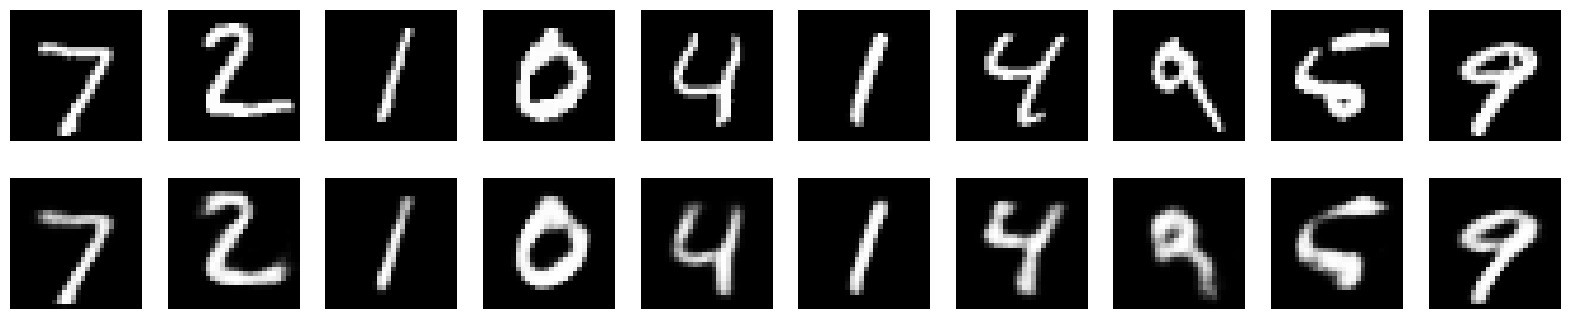

In [18]:
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original
    ax = plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis("off")

    # Reconstruction
    ax = plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()